In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.preprocessing import StandardScaler
from src.data_utils import load_california_housing

import sys
sys.path.append('..')

In [7]:
X, y = load_california_housing()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
results = []

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
train_r2 = lr.score(X_train_scaled, y_train)
test_r2 = lr.score(X_test_scaled, y_test)
n_nonzero = np.sum(lr.coef_ != 0)
results.append({
    'Method': 'LinearRegression',
    'Best α': 0,
    'Train R²': train_r2,
    'Test R²': test_r2,
    '# Non-zero coefficients': n_nonzero
})

In [8]:
models = {
    'Ridge': Ridge,
    'Lasso': Lasso,
    'ElasticNet': ElasticNet
}
alpha_scores = {name: [] for name in models.keys()}
best_models = {}
for model_name, ModelClass in models.items():
    best_alpha = None
    best_score = -np.inf
    best_model = None
    
    for alpha in alphas:
        if model_name == 'ElasticNet':
            model = ModelClass(alpha=alpha, l1_ratio=0.5, max_iter=10000)
        else:
            model = ModelClass(alpha=alpha, max_iter=10000)
        
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
        mean_score = cv_scores.mean()
        alpha_scores[model_name].append((alpha, mean_score))
        
        if mean_score > best_score:
            best_score = mean_score
            best_alpha = alpha
            best_model = model
    
    best_model.fit(X_train_scaled, y_train)
    train_r2 = best_model.score(X_train_scaled, y_train)
    test_r2 = best_model.score(X_test_scaled, y_test)
    n_nonzero = np.sum(np.abs(best_model.coef_) > 1e-5)
    
    best_models[model_name] = best_model
    
    results.append({
        'Method': model_name,
        'Best α': best_alpha,
        'Train R²': train_r2,
        'Test R²': test_r2,
        '# Non-zero coefficients': n_nonzero
    })

          Method  Best α  Train R²  Test R²  # Non-zero coefficients
LinearRegression    0.00  0.612551 0.575788                        8
           Ridge    0.01  0.612551 0.575788                        8
           Lasso    0.01  0.608474 0.581615                        7
      ElasticNet    0.01  0.610141 0.580319                        7


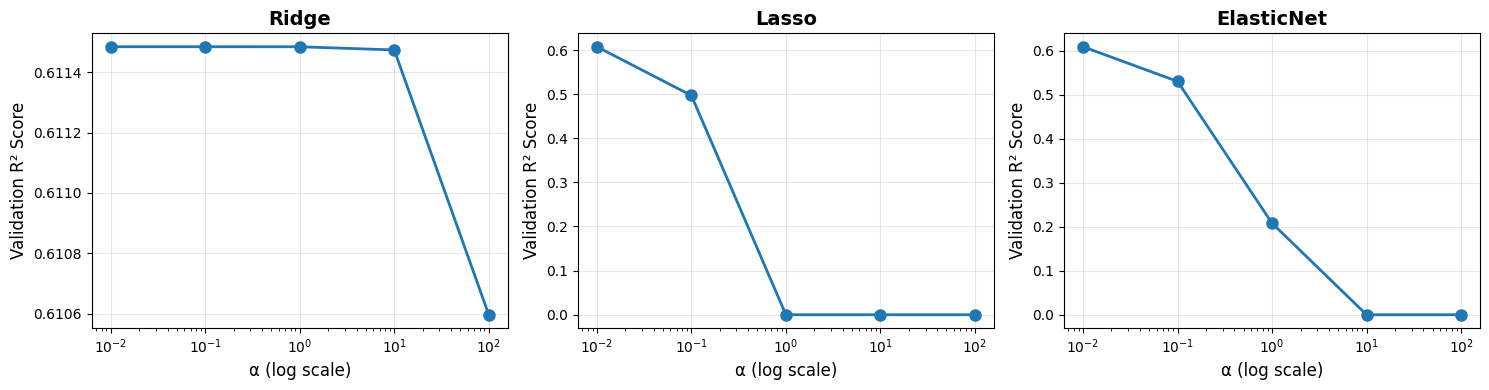

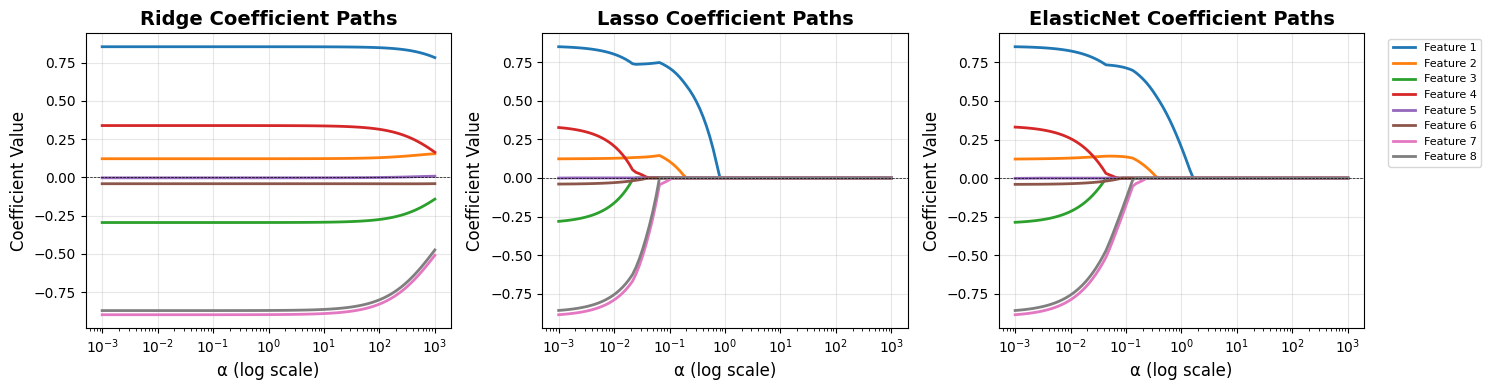

In [9]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (model_name, scores) in enumerate(alpha_scores.items()):
    alphas_list = [s[0] for s in scores]
    scores_list = [s[1] for s in scores]
    
    axes[idx].semilogx(alphas_list, scores_list, 'o-', linewidth=2, markersize=8)
    axes[idx].set_xlabel('α (log scale)', fontsize=12)
    axes[idx].set_ylabel('Validation R² Score', fontsize=12)
    axes[idx].set_title(f'{model_name}', fontsize=14, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

alphas_path = np.logspace(-3, 3, 100)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (model_name, ModelClass) in enumerate(models.items()):
    coefs = []
    for alpha in alphas_path:
        if model_name == 'ElasticNet':
            model = ModelClass(alpha=alpha, l1_ratio=0.5, max_iter=10000)
        else:
            model = ModelClass(alpha=alpha, max_iter=10000)
        model.fit(X_train_scaled, y_train)
        coefs.append(model.coef_)
    
    coefs = np.array(coefs)
    
    for i in range(coefs.shape[1]):
        axes[idx].plot(alphas_path, coefs[:, i], linewidth=2, label=f'Feature {i+1}')
    
    axes[idx].set_xscale('log')
    axes[idx].set_xlabel('α (log scale)', fontsize=12)
    axes[idx].set_ylabel('Coefficient Value', fontsize=12)
    axes[idx].set_title(f'{model_name} Coefficient Paths', fontsize=14, fontweight='bold')
    axes[idx].axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    axes[idx].grid(True, alpha=0.3)
    if idx == 2:
        axes[idx].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()


1. Lasso gives the highest Test $R^2$ with 0.5816

2. Lasso and ElasticNet produce sparsest solution with 7 non-zero coefficients

3. For Ridge they shrink smoothly but never reach zeros.
For both Lasso and Elastic Net they reach zeros but Elastic Net combines the behaviour of Ridge with Lasso and they need more time to reach the zeros for this method

4. Ridge keeps all features saying that they're all important as Lasso solutions suggest that some of the features are redundant